In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"

In [39]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data.csv") 

# id 열은 필요 없으니까 삭제
data = data.drop(columns="id",axis=1)

# 불균형 데이터

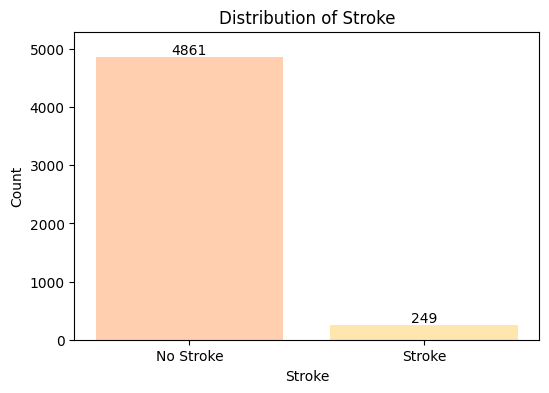

In [40]:
# 0과 1의 개수 계산
num_zeros = data['stroke'].value_counts()[0]
num_ones = data['stroke'].value_counts()[1]

# 그림 크기 조정
plt.figure(figsize=(6, 4))

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(['No Stroke', 'Stroke'], [num_zeros, num_ones], color = colors)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Distribution of Stroke')
plt.ylim(0, 5300)  # y 범위 설정 (start, end)

# 개수를 그래프에 텍스트로 표시
plt.text(0, num_zeros, f'{num_zeros}', ha='center', va='bottom')
plt.text(1, num_ones, f'{num_ones}', ha='center', va='bottom')

plt.savefig('stroke_count.png')

plt.show()

# 결측치

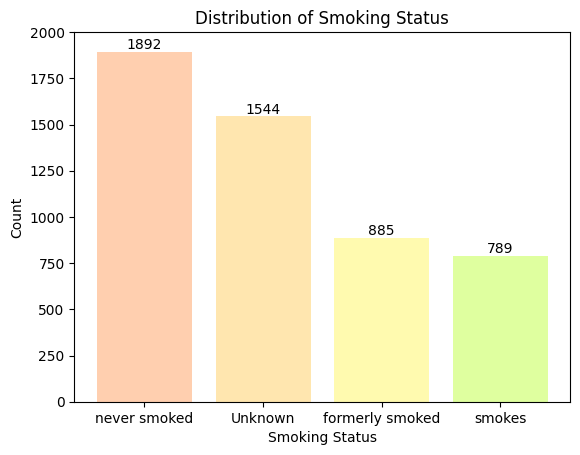

In [41]:
# 흡연 여부 칼럼 값의 개수 계산
value_counts = data['smoking_status'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Distribution of Smoking Status')
plt.ylim(0, 2000)  # y 범위 설정 (start, end)
# 개수를 그래프에 텍스트로 표시
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()

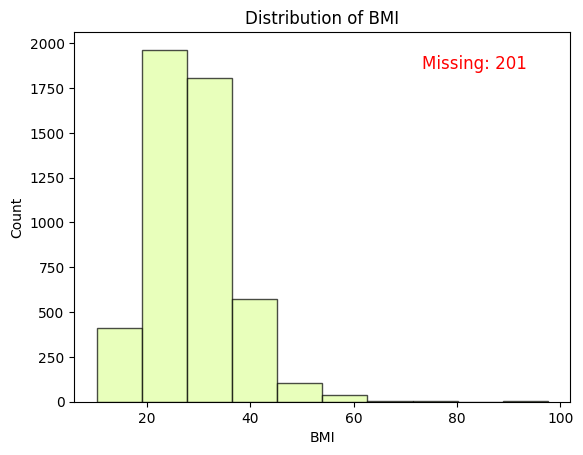

In [42]:
# 결측치 확인
missing_values = data['bmi'].isnull()

# 결측치 포함한 히스토그램
plt.hist(data['bmi'], bins=10, alpha=0.7, edgecolor='black', color = '#DFFF9F')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('Distribution of BMI')

# 결측치를 텍스트로 표시
missing_count = np.sum(missing_values)
plt.text(0.7, 0.9, f'Missing: {missing_count}', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.show()

# 이상치

성별

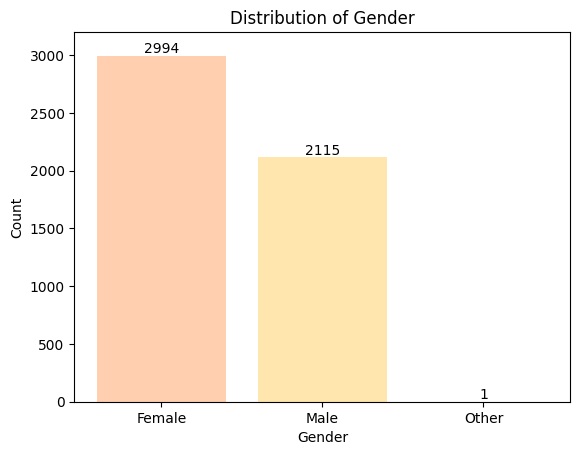

In [43]:
# 성별 칼럼 값의 개수 계산
value_counts = data['gender'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.ylim(0, 3200)
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()


bmi이상치 #결측치 제거하지않은 원본데이터

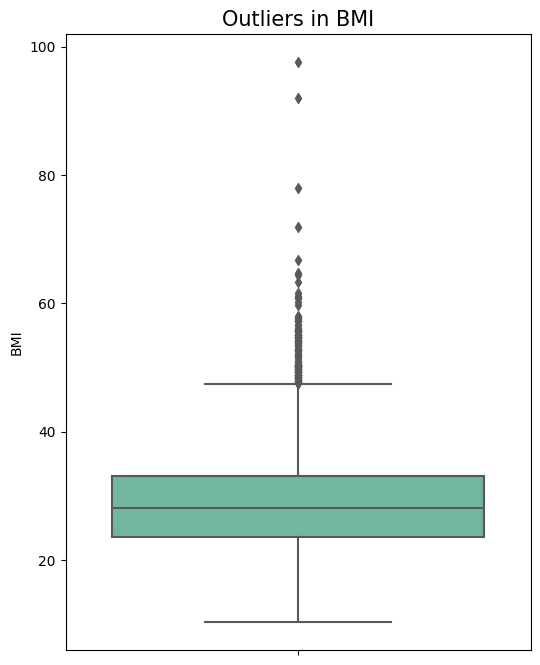

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

df = data.copy()

plt.figure(figsize=(6, 8))  # 그래프의 크기를 조정합니다.

sns.boxplot(y='bmi', data=df)

plt.title('Outliers in BMI', fontsize=15)
plt.ylabel('BMI')
plt.show()

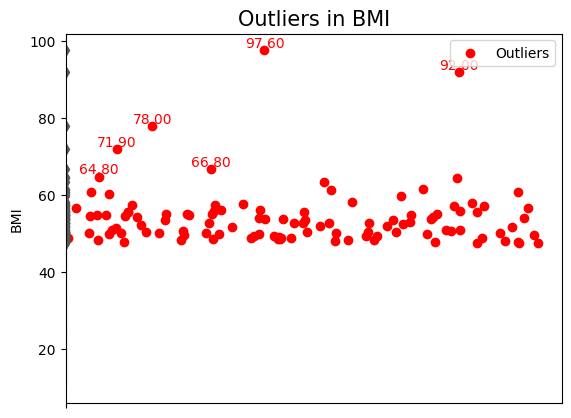

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

df = data.copy()

# 이상치를 확인하고 싶은 칼럼과 데이터프레임을 사용하여 이상치 시각화
sns.boxplot(y='bmi', data=df)

plt.title('Outliers in BMI', fontsize=15)
plt.ylabel('BMI')

# 이상치 데이터를 따로 표시
outliers = df[df['bmi'] > df['bmi'].quantile(0.75) + 1.5 * (df['bmi'].quantile(0.75) - df['bmi'].quantile(0.25))]
plt.scatter(x=outliers.index, y=outliers['bmi'], color='red', label='Outliers')

# 이상치로 판단된 상위 6개 값 표시
top_outliers = outliers.nlargest(6, 'bmi')
for i, outlier in top_outliers.iterrows():
    plt.text(i, outlier['bmi'], f'{outlier["bmi"]:.2f}', ha='center', va='bottom', color='red')

plt.legend()
plt.show()


In [46]:
# 이상치로 판단된 상위 6개 행 출력
outliers = df[df['bmi'] > df['bmi'].quantile(0.75) + 1.5 * (df['bmi'].quantile(0.75) - df['bmi'].quantile(0.25))]
top_outliers = outliers.nlargest(6, 'bmi')

print(top_outliers)

      gender   age  hypertension  heart_disease ever_married      work_type  \
2128    Male  17.0             1              0           No        Private   
4209    Male  38.0             1              0          Yes        Private   
928   Female  23.0             1              0           No        Private   
544     Male  42.0             0              0          Yes        Private   
1559  Female  53.0             0              0          Yes        Private   
358     Male  52.0             0              0          Yes  Self-employed   

     Residence_type  avg_glucose_level   bmi smoking_status  stroke  
2128          Rural              61.67  97.6        Unknown       0  
4209          Rural              56.90  92.0   never smoked       0  
928           Urban              70.03  78.0         smokes       0  
544           Rural             210.48  71.9   never smoked       0  
1559          Rural              72.63  66.8        Unknown       0  
358           Urban       

# 전체적인 분포

나이부분

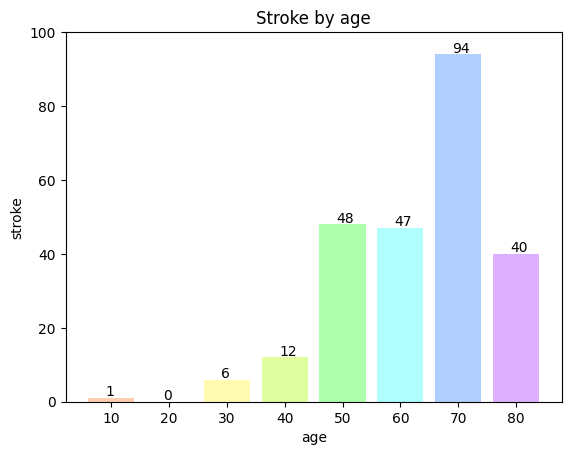

In [ ]:
def age_categorize(age):
  age = (age// 10) *10
  return age

age_category = data.age.apply(age_categorize)
age_category

data_age = data.copy()
data_age['age_category'] = age_category
data_age

# 리스트 만들기
stroke = []
age = []

for i in range(1,9):
  age.append(i*10)
  a = data_age.loc[data_age['age_category'] == i * 10.0]
  stroke.append(a['stroke'].sum())

xs = [i for i, _ in enumerate(age)]
colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F', '#AFFFAF', '#AFFFFF', '#AFCFFF', '#DFAFFF']

plt.bar(xs, stroke,color=colors)  # 해당 인덱스에 일치하는 값을 가진, 바 형태 그래프 생성
plt.xlabel("age")
plt.ylabel("stroke")
plt.xticks([i for i, _ in enumerate(age)], age)  # x 눈금 및 레이블 설정 
plt.title("Stroke by age")
plt.ylim(0, 100)  # y 범위 설정 (start, end)

for index, value in enumerate(stroke):
  plt.text(index - 0.1, value + 0.5, str(value))  # x 좌표, y 좌표, text
plt.show()

성별부분 # 이상치 제거한것

<ipython-input-10-a1a2daf15ce8>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['stroke'] = filtered_df['stroke'].map({0: 'no stroke', 1: 'stroke'})
<ipython-input-10-a1a2daf15ce8>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set2', 8).colors


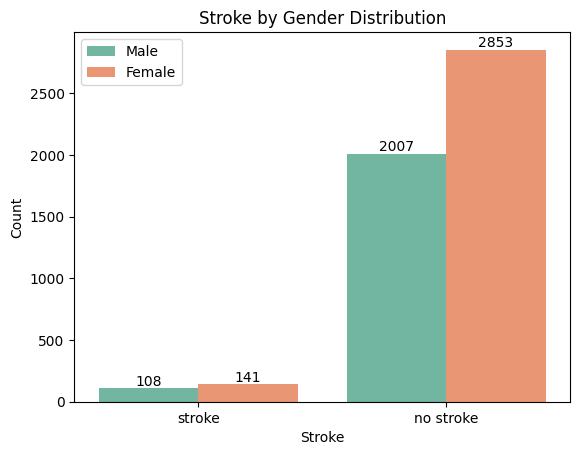

In [ ]:
from matplotlib import cm

# "other" 값을 제외한 데이터프레임 생성

filtered_df = data[data['gender'] != 'Other']

# 뇌졸중 여부를 "no stroke"와 "stroke"로 변환
filtered_df['stroke'] = filtered_df['stroke'].map({0: 'no stroke', 1: 'stroke'})

# 성별별 뇌졸중 여부 시각화
colors = cm.get_cmap('Set2', 8).colors
sns.set_palette(colors)
ax = sns.countplot(x='stroke', hue='gender', data=filtered_df)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke by Gender Distribution')

# 개수를 그래프에 정수로 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# 범례에 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = [label for label in labels if label != 'other']
ax.legend(handles, labels)

plt.show()


고혈압

<ipython-input-11-2d5d4392a627>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set2', 8).colors


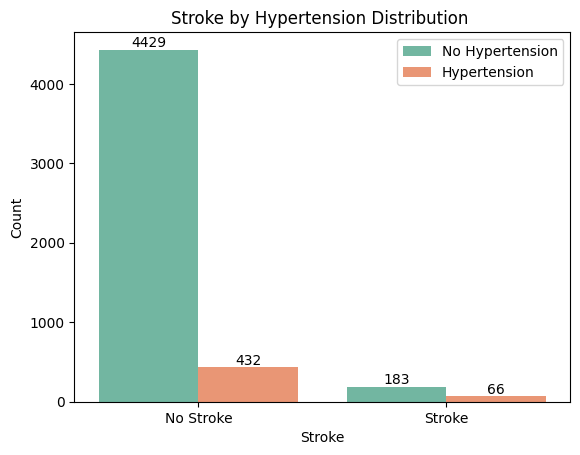

In [ ]:
from matplotlib import cm

# ColorBrewer의 Set2 컬러 맵 사용 (8개의 색상)
colors = cm.get_cmap('Set2', 8).colors
sns.set_palette(colors)

# 뇌졸중 여부에 따라 고혈압 여부를 시각화
ax = sns.countplot(x='stroke', hue='hypertension', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke by Hypertension Distribution ')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 개수를 그래프에 정수로 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# 범례 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = ['No Hypertension', 'Hypertension']
ax.legend(handles, labels)

plt.show()



심장병

<ipython-input-47-5ac8985f4cdb>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set2', 8).colors


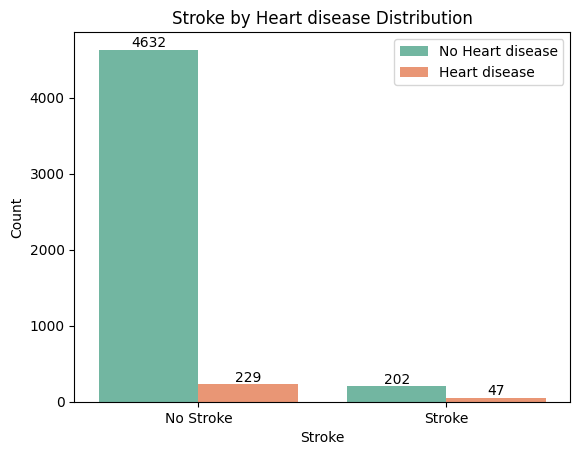

In [47]:
from matplotlib import cm

# ColorBrewer의 Set2 컬러 맵 사용 (8개의 색상)
colors = cm.get_cmap('Set2', 8).colors
sns.set_palette(colors)

# 뇌졸중 여부에 따라 고혈압 여부를 시각화
ax = sns.countplot(x='stroke', hue='heart_disease', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke by Heart disease Distribution')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 개수를 그래프에 정수로 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# 범례 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = ['No Heart disease', 'Heart disease']
ax.legend(handles, labels)

plt.show()

결혼

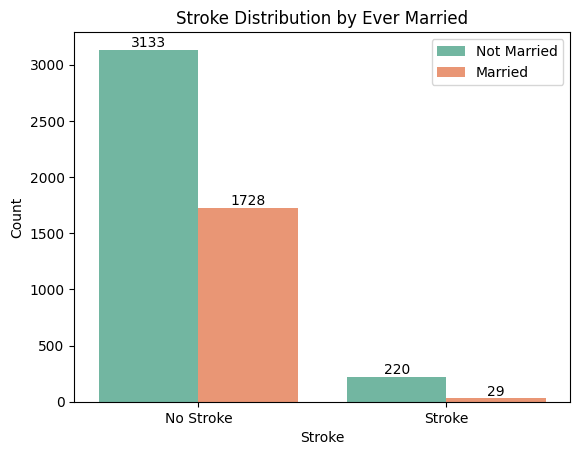

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='ever_married', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Ever Married')

# 각 막대에 정수형 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 범례 레이블 수정
handles, labels = ax.get_legend_handles_labels()
labels = ['Not Married', 'Married']
ax.legend(handles, labels)

plt.show()


직업

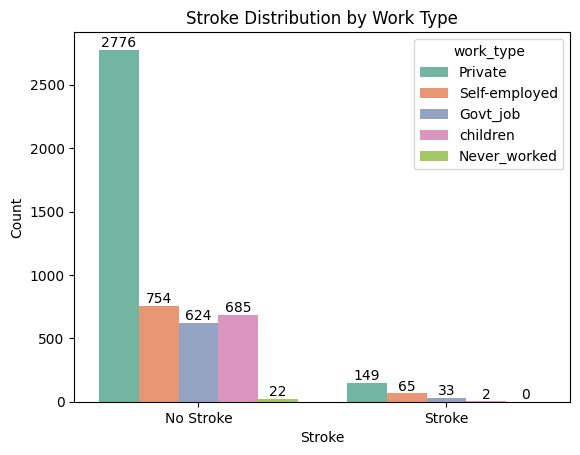

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='work_type', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Work Type')

# 각 막대에 정수형 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


거주지역

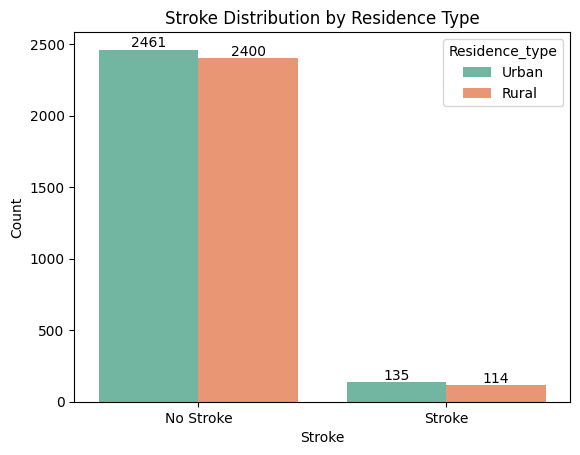

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='Residence_type', data=data)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Residence Type')

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


흡연여부

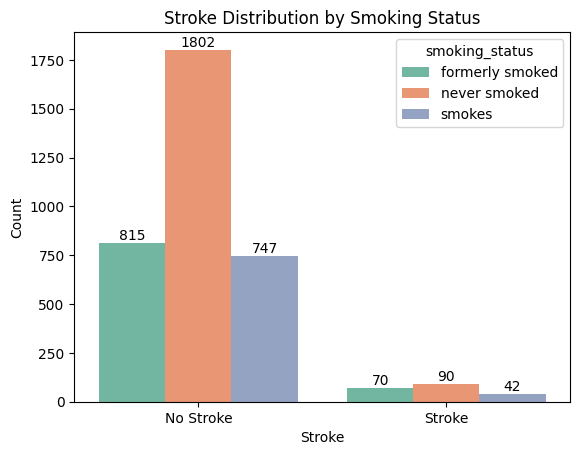

In [ ]:
# 'Unknown' 제외한 데이터 필터링
filtered_df = data[data['smoking_status'] != 'Unknown']

# 시각화
ax = sns.countplot(x='stroke', hue='smoking_status', data=filtered_df)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Smoking Status')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

plt.show()

혈당수치

<ipython-input-17-42830e3e764b>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 0]["avg_glucose_level"], color='green', label='No Stroke') # No Stroke - green
<ipython-input-17-42830e3e764b>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 1]["avg_g

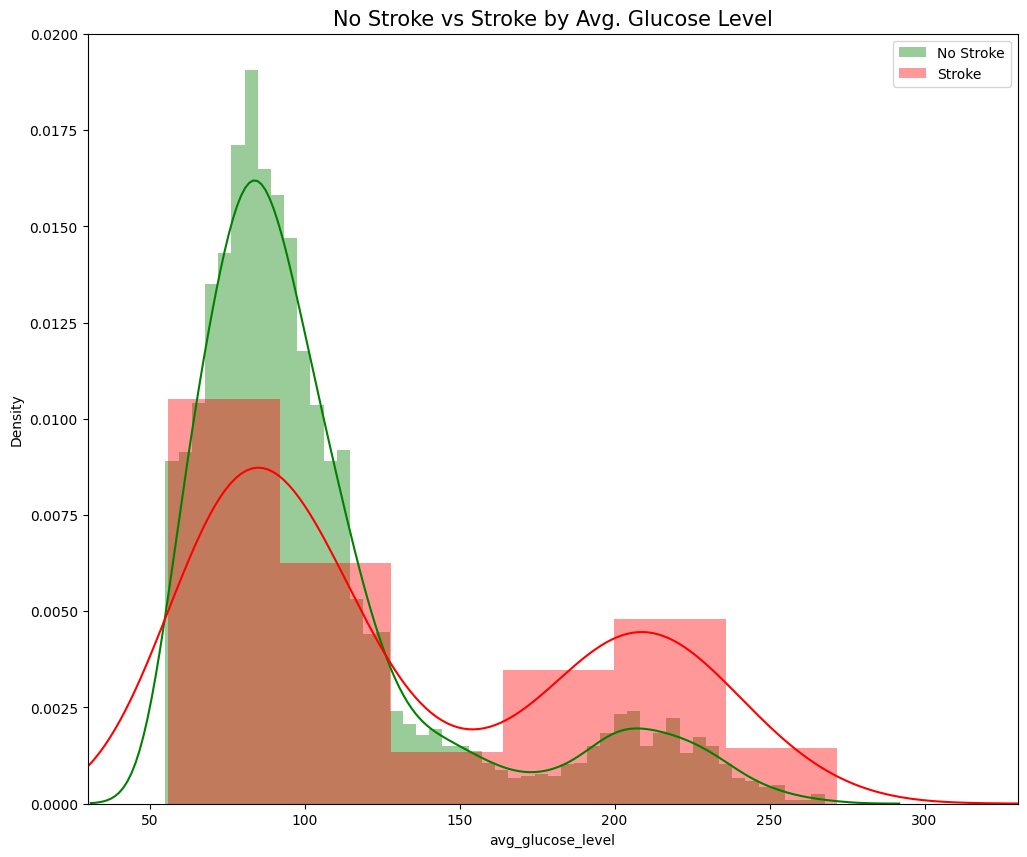

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.distplot(data[data['stroke'] == 0]["avg_glucose_level"], color='green', label='No Stroke') # No Stroke - green
sns.distplot(data[data['stroke'] == 1]["avg_glucose_level"], color='red', label='Stroke') # Stroke - Red

plt.title('No Stroke vs Stroke by Avg. Glucose Level', fontsize=15)
plt.xlim([30,330])

# 범례 추가
plt.legend()

plt.show()


bmi

<ipython-input-18-1ebef17fa037>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 0]["bmi"], color='green', label='No Stroke') # No Stroke - green
<ipython-input-18-1ebef17fa037>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['stroke'] == 1]["bmi"], color='red',

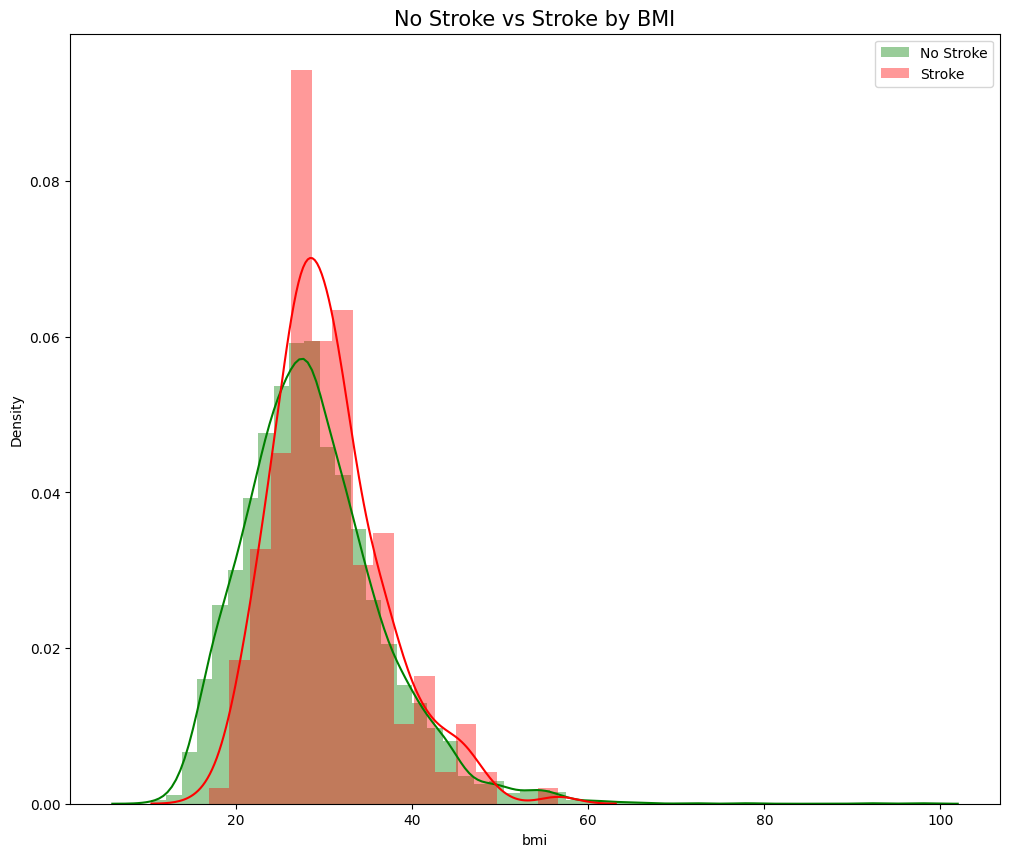

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.distplot(data[data['stroke'] == 0]["bmi"], color='green', label='No Stroke') # No Stroke - green
sns.distplot(data[data['stroke'] == 1]["bmi"], color='red', label='Stroke') # Stroke - Red

plt.title('No Stroke vs Stroke by BMI', fontsize=15)

# 범례 추가
plt.legend()

plt.show()